In [141]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
from Bio import SeqIO
import matplotlib.pyplot as plt
from Bio.Data import CodonTable
from sklearn.decomposition import NMF
from sklearn.preprocessing import normalize
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test
from statsmodels.stats.multitest import multipletests
from sklearn.mixture import GaussianMixture
from scipy.stats import gaussian_kde
from scipy.signal import find_peaks

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from scipy.stats import chi2_contingency, ttest_ind
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, roc_curve, precision_recall_curve, auc
from xgboost import XGBClassifier

In [2]:
def read_gene_expression(file_path):
    df = pd.read_csv(file_path, sep='\t')
    return df

def read_somatic_mutations(file_path):
    df = pd.read_csv(file_path, sep='\t')
    return df

def read_patient_metadata(file_path):
    df = pd.read_csv(file_path, sep='\t')
    return df


def handle_missing_data(df: pd.DataFrame,
                        subset_cols: list = None,
                        method: str = "drop") -> pd.DataFrame:

    if method == "drop":
        if subset_cols:
            return df.dropna(subset=subset_cols)
        return df.dropna()
    elif method == "fill":
        numeric = df.select_dtypes(include=[np.number]).columns
        df[numeric] = df[numeric].fillna(df[numeric].mean())
        return df
    else:
        raise ValueError("method must be 'drop' or 'fill'")

def kaplan_meier_survival(df: pd.DataFrame,
                          time_col: str = 'DSS.time',
                          event_col: str = 'DSS') -> KaplanMeierFitter:

    km_df = df[[time_col, event_col]].copy()
    km_df[time_col] = pd.to_numeric(km_df[time_col], errors='coerce')
    km_df[event_col] = pd.to_numeric(km_df[event_col], errors='coerce')
    km_df = handle_missing_data(km_df, subset_cols=[time_col, event_col], method="drop")
    if km_df.empty:
        raise ValueError("No data left for KM after cleaning")
    kmf = KaplanMeierFitter()
    kmf.fit(durations=km_df[time_col], event_observed=km_df[event_col])
    kmf.plot_survival_function()
    return kmf

def cox_proportional_hazards(df: pd.DataFrame,
                             time_col: str,
                             event_col: str,
                             numeric_covs: list,
                             categorical_covs: list) -> CoxPHFitter:

    cph_df = df[[time_col, event_col] + numeric_covs + categorical_covs].copy()
    cph_df[time_col] = pd.to_numeric(cph_df[time_col], errors='coerce')
    cph_df[event_col] = pd.to_numeric(cph_df[event_col], errors='coerce')
    cph_df = handle_missing_data(cph_df, subset_cols=[time_col, event_col] + numeric_covs, method="drop")
    if cph_df.empty:
        raise ValueError("No data left for CoxPH after cleaning")
    cph_df = pd.get_dummies(cph_df, columns=categorical_covs, drop_first=True)
    cph = CoxPHFitter()
    cph.fit(cph_df, duration_col=time_col, event_col=event_col)
    return cph

def add_mutation_status_column(df: pd.DataFrame,
                               gene_col: str = 'Hugo_Symbol',
                               mutation_gene: str = 'TP53') -> pd.DataFrame:

    df = df.copy()
    df['mutation_status'] = np.where(df[gene_col] == mutation_gene,
                                     'mutant',
                                     'wildtype')
    return df


def compute_tmb(somatic_mut: pd.DataFrame) -> pd.Series:
    tmb = somatic_mut['patient_id'].value_counts()
    tmb.name = 'TMB'
    return tmb

Log10 split: 2.858
Exact split: 721 mutations


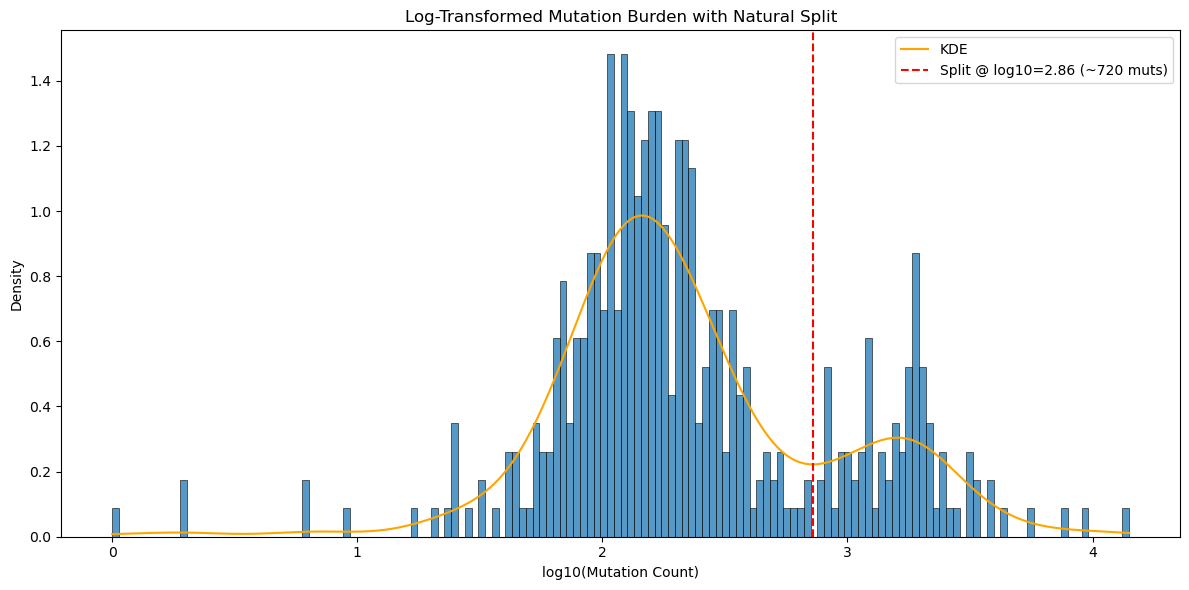

In [3]:
somatic_mut = read_somatic_mutations("/Users/shuhaoxu/Desktop/BNFO285/Groupproject/Project2/TCGA.STAD.mutations.txt")
mutation_counts = somatic_mut['patient_id'].value_counts().sort_index()
counts_array = mutation_counts[mutation_counts > 0].values.astype(float)
log_counts = np.log10(counts_array)

kde = gaussian_kde(log_counts)
x_vals = np.linspace(log_counts.min(), log_counts.max(), 1000)
kde_vals = kde(x_vals)
mask = (x_vals > 1.5) & (x_vals < 3.5)
x_zoom = x_vals[mask]
kde_zoom = kde_vals[mask]

# Find trough (local minimum)
troughs, _ = find_peaks(-kde_zoom)
if len(troughs) > 0:
    log_split = x_zoom[troughs[0]]
    exact_split = 10**log_split
    print(f"Log10 split: {log_split:.3f}")
    print(f"Exact split: {exact_split:.0f} mutations")
else:
    log_split = None
    print("No trough found.")

# Plot
plt.figure(figsize=(12, 6))
sns.histplot(log_counts, bins=150, kde=False, stat="density")
plt.plot(x_vals, kde_vals, color='orange', label='KDE')

# Plot vertical line for the split
if log_split:
    plt.axvline(log_split, color='red', linestyle='--', label=f"Split @ log10={log_split:.2f} (~{int(exact_split)} muts)")

plt.xlabel("log10(Mutation Count)")
plt.ylabel("Density")
plt.title("Log-Transformed Mutation Burden with Natural Split")
plt.legend()
plt.tight_layout()
plt.show()

In [26]:
hist_bins = np.histogram_bin_edges(log_counts, bins=50)
linear_bins = 10 ** hist_bins
bin_aligned_split = linear_bins[linear_bins < exact_split].max()
print(f"Adjusted split (previous bin edge): {bin_aligned_split:.0f} mutations")

Adjusted split (previous bin edge): 663 mutations


In [5]:
threshold = bin_aligned_split
mutation_counts = somatic_mut['patient_id'].value_counts().sort_index()
mutation_split_df = mutation_counts.to_frame(name="mutation_count")

# Assign groups
mutation_split_df["mutation_group"] = mutation_split_df["mutation_count"].apply(
    lambda x: "High" if x >= threshold else "Low"
)

# Split into patient ID lists
low_patients = mutation_split_df[mutation_split_df["mutation_group"] == "Low"].index.tolist()
high_patients = mutation_split_df[mutation_split_df["mutation_group"] == "High"].index.tolist()

# Filter original mutation rows
low_mut = somatic_mut[somatic_mut['patient_id'].isin(low_patients)]
high_mut = somatic_mut[somatic_mut['patient_id'].isin(high_patients)]

In [6]:
expression = pd.read_csv("/Users/shuhaoxu/Desktop/BNFO285/Groupproject/Project2/TCGA.STAD.expression.txt", sep="\t")
expression.set_index(["patient_id"], inplace=True)
expression = expression.drop("sample_id", axis=1)
expression = expression.fillna(0)
metadata = pd.read_csv("/Users/shuhaoxu/Desktop/BNFO285/Groupproject/Project2/TCGA.STAD.metadata.txt", sep="\t")
metadata.set_index("patient_id", inplace=True)

In [231]:
metadata.shape

(415, 18)

In [251]:
metadata.OS.value_counts()

OS
0.0    255
1.0    160
Name: count, dtype: int64

# All

/var/folders/42/x61503vj4jx8wmb1ts75xmyh0000gn/T/ipykernel_11112/4246938642.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  low_metadata['y'] = low_metadata['OS']
/Users/shuhaoxu/mambaforge/envs/singlecell/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/Users/shuhaoxu/mambaforge/envs/singlecell/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may 

(324, 2216)
(322, 2216)

Training Random Forest...
Best parameters for Random Forest: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 100}

Training Logistic Regression...
Best parameters for Logistic Regression: {'C': 0.1, 'solver': 'lbfgs'}

Training SVM...
Best parameters for SVM: {'C': 10, 'kernel': 'rbf'}

Model Performance Comparison:
                 Model   AUC-ROC    AUC-PR  Precision    Recall        F1
0        Random Forest  0.693192  0.639202   0.733333  0.282051  0.407407
1  Logistic Regression  0.844385  0.793948   0.774194  0.615385  0.685714
2                  SVM  0.866490  0.824236   0.806452  0.641026  0.714286


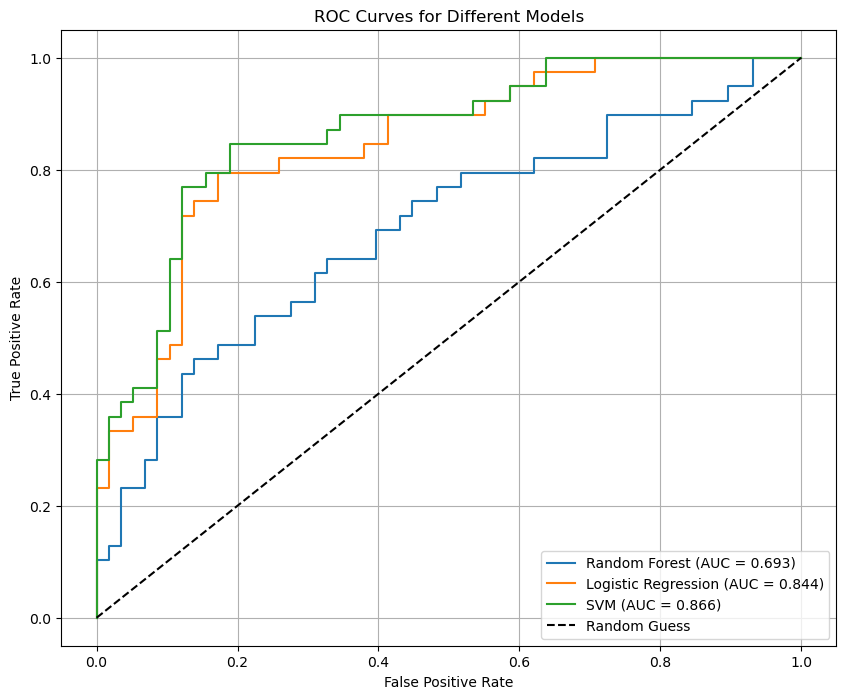

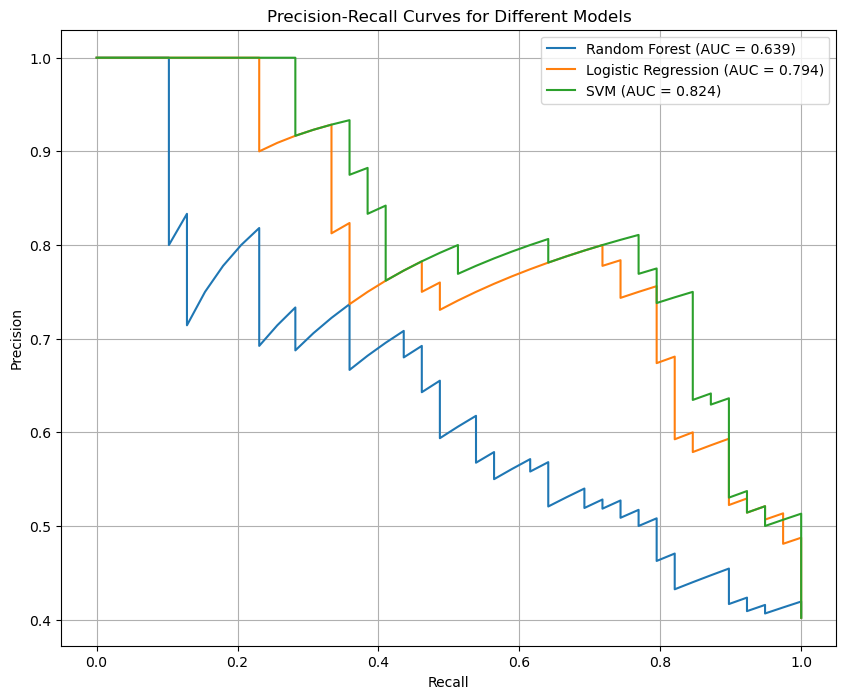

In [304]:
low_mut_metadata = metadata
low_mut_patients = set(low_mut_metadata.index)
low_mutation_matrix = pd.crosstab(
    index=low_mut['patient_id'],
    columns=low_mut['Hugo_Symbol'],
    values=1, 
    aggfunc='count'
)
low_mutation_matrix = low_mutation_matrix.fillna(0)
low_mutation_matrix = low_mutation_matrix[low_mutation_matrix.index.isin(low_mut_patients)]
low_exp_matrix = expression[expression.index.isin(low_mut_patients)]

low_metadata = low_mut_metadata.dropna(subset=['OS', 'OS.time'])
low_metadata['y'] = low_metadata['OS']

common_patients = low_metadata.index.intersection(low_mutation_matrix.index).intersection(low_exp_matrix.index)
X_mut = low_mutation_matrix.loc[common_patients]
X_exp = low_exp_matrix.loc[common_patients]
X_clinical = low_metadata.loc[common_patients, ['age_at_initial_pathologic_diagnosis', 'gender', 'race', 
                                                 'ajcc_pathologic_tumor_stage', 'histological_type', 
                                                 'histological_grade', 'tumor_status']]
y = low_metadata.loc[common_patients, 'y']

# Step 3: Feature Selection
# 3.1: Mutation Features - Filter genes with low mutation frequency (< 5%)
mutation_freq = X_mut.mean()
selected_mut_genes = mutation_freq[mutation_freq >= 0.05].index
X_mut_selected = X_mut[selected_mut_genes]

# 3.2: Gene Expression Features - Standardize and filter low-variance genes
scaler = StandardScaler()
X_exp_scaled = pd.DataFrame(scaler.fit_transform(X_exp), index=X_exp.index, columns=X_exp.columns)
exp_variance = X_exp_scaled.var()
selected_exp_genes = exp_variance[exp_variance > 0.01].index  # Keep genes with variance > 0.01
X_exp_selected = X_exp_scaled[selected_exp_genes]

# 3.3: Clinical Features - Encode categorical variables
# Define which columns are categorical
categorical_cols = ['gender', 'race', 'ajcc_pathologic_tumor_stage', 'histological_type', 'histological_grade', 'tumor_status']
numerical_cols = ['age_at_initial_pathologic_diagnosis']

# Use ColumnTransformer to encode categorical variables
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_cols),
        ('num', 'passthrough', numerical_cols)
    ])

X_clinical_encoded = pd.DataFrame(
    preprocessor.fit_transform(X_clinical),
    index=X_clinical.index,
    columns=(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols).tolist() + numerical_cols)
)

# 3.4: Univariate Feature Selection for Mutation and Expression Features
# For binary features (mutation), use chi-squared test
mut_p_values = {}
for col in X_mut_selected.columns:
    contingency_table = pd.crosstab(X_mut_selected[col], y)
    chi2, p, _, _ = chi2_contingency(contingency_table)
    mut_p_values[col] = p

# t-test
exp_p_values = {}
for col in X_exp_selected.columns:
    group0 = X_exp_selected[col][y == 0]
    group1 = X_exp_selected[col][y == 1]
    t_stat, p = ttest_ind(group0, group1, nan_policy='omit')
    exp_p_values[col] = p

# Select features
selected_mut_features = [col for col, p in mut_p_values.items() if p < 0.1]
selected_exp_features = [col for col, p in exp_p_values.items() if p < 0.1]
X_mut_final = X_mut_selected[selected_mut_features]
X_exp_final = X_exp_selected[selected_exp_features]

X_exp_final = X_exp_final.loc[~X_exp_final.index.duplicated(keep='first')]
X = X_mut_final.join(X_exp_final).join(X_clinical_encoded)
print(X.shape)

X = X.dropna()
print(X.shape)

y = y[y.index.isin(X.index)]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

# Sanitize feature names to remove problematic characters (e.g., [], <)
X_train.columns = [col.replace('[', '').replace(']', '').replace('<', '') for col in X_train.columns]
X_test.columns = [col.replace('[', '').replace(']', '').replace('<', '') for col in X_test.columns]

# Step 5: Train Multiple Models with Cross-Validation
models = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=3000),
    'SVM': SVC(probability=True, random_state=42),
}

# Hyperparameter grids for tuning
param_grids = {
    'Random Forest': {
        'n_estimators': [100, 150, 200, 250, 300],
        'max_depth': [3, 5, 7, 10, 15, 20, None],
        'min_samples_split': [2, 3, 4, 5]
    },
    'Logistic Regression': {
        'C': [0.1, 0.5, 1, 1.5, 2, 4, 5, 8, 10],
        'solver': ['lbfgs', 'liblinear', 'newton-cg', 'sag']
    },
    'SVM': {
        'C': [0.1, 0.5, 1, 1.5, 2, 4, 5, 8, 10],
        'kernel': ['rbf', 'linear']
    },
}

# Dictionary to store the best models and their performance
best_models = {}
metrics = {'Model': [], 'AUC-ROC': [], 'AUC-PR': [], 'Precision': [], 'Recall': [], 'F1': []}
roc_data = {}
pr_data = {}

# Train and evaluate each model
for model_name, model in models.items():
    print(f"\nTraining {model_name}...")
    grid_search = GridSearchCV(model, param_grids[model_name], cv=5, scoring='roc_auc', n_jobs=-1)
    grid_search.fit(X_train, y_train)
    
    # Best model
    best_model = grid_search.best_estimator_
    best_models[model_name] = best_model
    print(f"Best parameters for {model_name}:", grid_search.best_params_)
    
    # Predictions and probabilities
    y_pred = best_model.predict(X_test)
    y_pred_proba = best_model.predict_proba(X_test)[:, 1] if hasattr(best_model, "predict_proba") else best_model.decision_function(X_test)
    
    # Compute metrics
    auc_roc = roc_auc_score(y_test, y_pred_proba)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_data[model_name] = (fpr, tpr, auc_roc)
    
    # Precision-Recall Curve
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_pred_proba)
    auc_pr = auc(recall_vals, precision_vals)
    pr_data[model_name] = (recall_vals, precision_vals, auc_pr)
    
    # Store metrics
    metrics['Model'].append(model_name)
    metrics['AUC-ROC'].append(auc_roc)
    metrics['AUC-PR'].append(auc_pr)
    metrics['Precision'].append(precision)
    metrics['Recall'].append(recall)
    metrics['F1'].append(f1)

# Print metrics in a table
metrics_df = pd.DataFrame(metrics)
print("\nModel Performance Comparison:")
print(metrics_df)

# Step 6: Plot ROC Curves
plt.figure(figsize=(10, 8))
for model_name, (fpr, tpr, auc_roc) in roc_data.items():
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc_roc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Different Models')
plt.legend()
plt.grid()
plt.show()

# Step 7: Plot Precision-Recall Curves
plt.figure(figsize=(10, 8))
for model_name, (recall_vals, precision_vals, auc_pr) in pr_data.items():
    plt.plot(recall_vals, precision_vals, label=f'{model_name} (AUC = {auc_pr:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves for Different Models')
plt.legend()
plt.grid()
plt.show()

In [305]:
for model_name in ['Random Forest']:
    if model_name in best_models:
        print(f"\nTop 10 Most Important Features for {model_name}:")
        model = best_models[model_name]
        feature_importance = pd.Series(model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
        print(feature_importance.head(20))


Top 10 Most Important Features for Random Forest:
MAPK14|1432        0.006348
APOA5|116519       0.006081
KPTN|11133         0.004968
TSPO2|222642       0.004941
LBP|3929           0.004634
ZDHHC19|131540     0.004563
CSRNP1|64651       0.004452
C3orf19|51244      0.004439
PACS1|55690        0.004433
UBA3|9039          0.003932
SELPLG|6404        0.003854
C17orf97|400566    0.003830
GAMT|2593          0.003719
KRT85|3891         0.003634
FLOT1|10211        0.003595
KDM4D|55693        0.003590
C19orf26|255057    0.003570
CXorf58|254158     0.003547
HBG2|3048          0.003543
PLEKHM1P|440456    0.003486
dtype: float64


# Low

In [289]:
low_mut_metadata = metadata[metadata.index.isin(low_mut.patient_id)]

In [291]:
os_0 = low_mut_metadata[low_mut_metadata.OS == 0].sample(n=130, random_state=42)
os_1 = low_mut_metadata[low_mut_metadata.OS == 1].sample(n=130, random_state=42)
low_mut_metadata = pd.concat([os_0, os_1])

In [294]:
low_mut_patients = set(low_mut_metadata.index)
low_mutation_matrix = pd.crosstab(
    index=low_mut['patient_id'],
    columns=low_mut['Hugo_Symbol'],
    values=1, 
    aggfunc='count'
)
low_mutation_matrix = low_mutation_matrix.fillna(0)
low_mutation_matrix = low_mutation_matrix[low_mutation_matrix.index.isin(low_mut_patients)]
low_exp_matrix = expression[expression.index.isin(low_mut_patients)]

low_metadata = low_mut_metadata.dropna(subset=['OS', 'OS.time'])
low_metadata['y'] = low_metadata['OS']

common_patients = low_metadata.index.intersection(low_mutation_matrix.index).intersection(low_exp_matrix.index)
X_mut = low_mutation_matrix.loc[common_patients]
X_exp = low_exp_matrix.loc[common_patients]
X_clinical = low_metadata.loc[common_patients, ['age_at_initial_pathologic_diagnosis', 'gender', 'race', 
                                                 'ajcc_pathologic_tumor_stage', 'histological_type', 
                                                 'histological_grade', 'tumor_status']]
y = low_metadata.loc[common_patients, 'y']

# Step 3: Feature Selection
# 3.1: Mutation Features - Filter genes with low mutation frequency (< 5%)
mutation_freq = X_mut.mean()
selected_mut_genes = mutation_freq[mutation_freq >= 0.05].index
X_mut_selected = X_mut[selected_mut_genes]

# 3.2: Gene Expression Features - Standardize and filter low-variance genes
scaler = StandardScaler()
X_exp_scaled = pd.DataFrame(scaler.fit_transform(X_exp), index=X_exp.index, columns=X_exp.columns)
exp_variance = X_exp_scaled.var()
selected_exp_genes = exp_variance[exp_variance > 0.01].index  # Keep genes with variance > 0.01
X_exp_selected = X_exp_scaled[selected_exp_genes]

# 3.3: Clinical Features - Encode categorical variables
# Define which columns are categorical
categorical_cols = ['gender', 'race', 'ajcc_pathologic_tumor_stage', 'histological_type', 'histological_grade', 'tumor_status']
numerical_cols = ['age_at_initial_pathologic_diagnosis']

# Use ColumnTransformer to encode categorical variables
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_cols),
        ('num', 'passthrough', numerical_cols)
    ])

X_clinical_encoded = pd.DataFrame(
    preprocessor.fit_transform(X_clinical),
    index=X_clinical.index,
    columns=(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols).tolist() + numerical_cols)
)

# 3.4: Univariate Feature Selection for Mutation and Expression Features
# For binary features (mutation), use chi-squared test
mut_p_values = {}
for col in X_mut_selected.columns:
    contingency_table = pd.crosstab(X_mut_selected[col], y)
    chi2, p, _, _ = chi2_contingency(contingency_table)
    mut_p_values[col] = p

# t-test
exp_p_values = {}
for col in X_exp_selected.columns:
    group0 = X_exp_selected[col][y == 0]
    group1 = X_exp_selected[col][y == 1]
    t_stat, p = ttest_ind(group0, group1, nan_policy='omit')
    exp_p_values[col] = p

# Select features
selected_mut_features = [col for col, p in mut_p_values.items() if p < 0.1]
selected_exp_features = [col for col, p in exp_p_values.items() if p < 0.1]
X_mut_final = X_mut_selected[selected_mut_features]
X_exp_final = X_exp_selected[selected_exp_features]

/var/folders/42/x61503vj4jx8wmb1ts75xmyh0000gn/T/ipykernel_11112/4016051329.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  low_metadata['y'] = low_metadata['OS']


In [295]:
X_exp_final = X_exp_final.loc[~X_exp_final.index.duplicated(keep='first')]
X = X_mut_final.join(X_exp_final).join(X_clinical_encoded)
X.shape

(256, 1706)

In [296]:
X = X.dropna()
X.shape

(256, 1706)

In [297]:
y = y[y.index.isin(X.index)]

In [301]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

# Sanitize feature names to remove problematic characters (e.g., [], <)
X_train.columns = [col.replace('[', '').replace(']', '').replace('<', '') for col in X_train.columns]
X_test.columns = [col.replace('[', '').replace(']', '').replace('<', '') for col in X_test.columns]


Training Random Forest...
Best parameters for Random Forest: {'max_depth': 7, 'min_samples_split': 3, 'n_estimators': 150}

Training Logistic Regression...
Best parameters for Logistic Regression: {'C': 0.1, 'solver': 'liblinear'}

Training SVM...
Best parameters for SVM: {'C': 0.1, 'kernel': 'linear'}

Model Performance Comparison:
                 Model   AUC-ROC    AUC-PR  Precision    Recall        F1
0        Random Forest  0.675439  0.601693   0.619048  0.684211  0.650000
1  Logistic Regression  0.881242  0.874325   0.805556  0.763158  0.783784
2                  SVM  0.860999  0.871234   0.882353  0.789474  0.833333


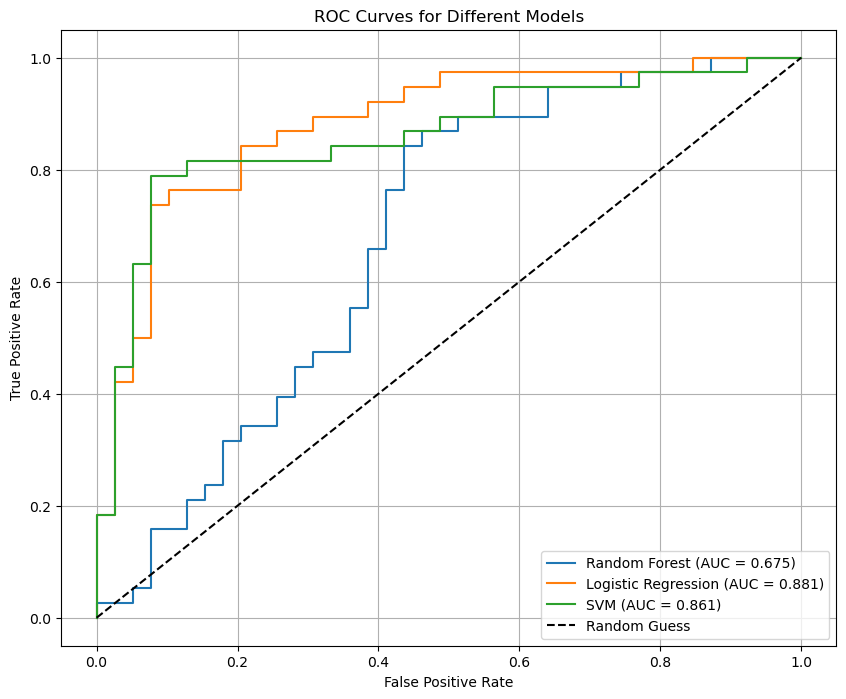

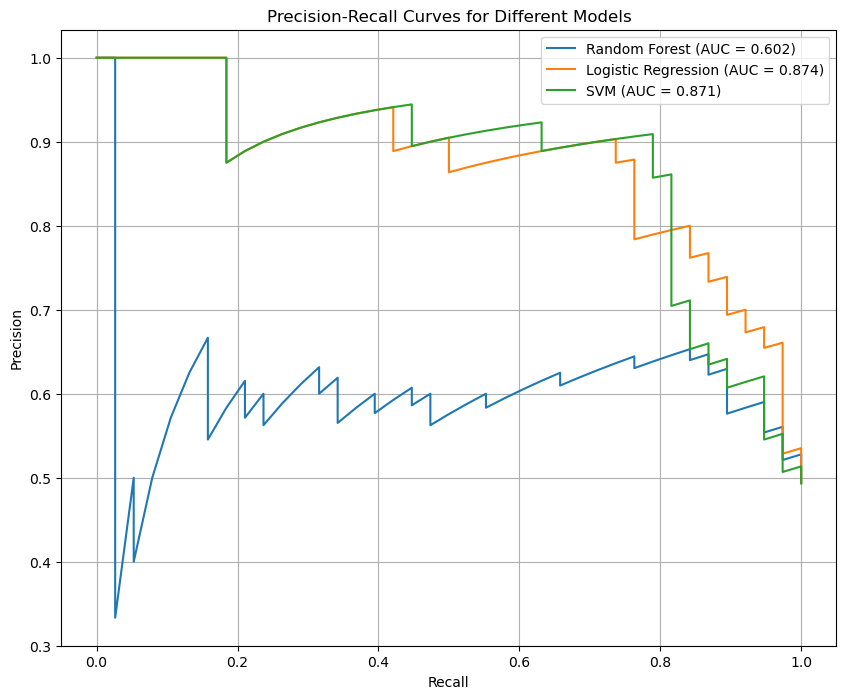

In [302]:
# Step 5: Train Multiple Models with Cross-Validation
models = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=3000),
    'SVM': SVC(probability=True, random_state=42),
}

# Hyperparameter grids for tuning
param_grids = {
    'Random Forest': {
        'n_estimators': [100, 150, 200, 250, 300],
        'max_depth': [3, 5, 7, 10, 15, 20, None],
        'min_samples_split': [2, 3, 4, 5]
    },
    'Logistic Regression': {
        'C': [0.1, 0.5, 1, 1.5, 2, 4, 5, 8, 10],
        'solver': ['lbfgs', 'liblinear', 'newton-cg', 'sag']
    },
    'SVM': {
        'C': [0.1, 0.5, 1, 1.5, 2, 4, 5, 8, 10],
        'kernel': ['rbf', 'linear']
    },
}

# Dictionary to store the best models and their performance
best_models = {}
metrics = {'Model': [], 'AUC-ROC': [], 'AUC-PR': [], 'Precision': [], 'Recall': [], 'F1': []}
roc_data = {}
pr_data = {}

# Train and evaluate each model
for model_name, model in models.items():
    print(f"\nTraining {model_name}...")
    grid_search = GridSearchCV(model, param_grids[model_name], cv=5, scoring='roc_auc', n_jobs=-1)
    grid_search.fit(X_train, y_train)
    
    # Best model
    best_model = grid_search.best_estimator_
    best_models[model_name] = best_model
    print(f"Best parameters for {model_name}:", grid_search.best_params_)
    
    # Predictions and probabilities
    y_pred = best_model.predict(X_test)
    y_pred_proba = best_model.predict_proba(X_test)[:, 1] if hasattr(best_model, "predict_proba") else best_model.decision_function(X_test)
    
    # Compute metrics
    auc_roc = roc_auc_score(y_test, y_pred_proba)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_data[model_name] = (fpr, tpr, auc_roc)
    
    # Precision-Recall Curve
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_pred_proba)
    auc_pr = auc(recall_vals, precision_vals)
    pr_data[model_name] = (recall_vals, precision_vals, auc_pr)
    
    # Store metrics
    metrics['Model'].append(model_name)
    metrics['AUC-ROC'].append(auc_roc)
    metrics['AUC-PR'].append(auc_pr)
    metrics['Precision'].append(precision)
    metrics['Recall'].append(recall)
    metrics['F1'].append(f1)

# Print metrics in a table
metrics_df = pd.DataFrame(metrics)
print("\nModel Performance Comparison:")
print(metrics_df)

# Step 6: Plot ROC Curves
plt.figure(figsize=(10, 8))
for model_name, (fpr, tpr, auc_roc) in roc_data.items():
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc_roc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Different Models')
plt.legend()
plt.grid()
plt.show()

# Step 7: Plot Precision-Recall Curves
plt.figure(figsize=(10, 8))
for model_name, (recall_vals, precision_vals, auc_pr) in pr_data.items():
    plt.plot(recall_vals, precision_vals, label=f'{model_name} (AUC = {auc_pr:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves for Different Models')
plt.legend()
plt.grid()
plt.show()

In [303]:
for model_name in ['Random Forest']:
    if model_name in best_models:
        print(f"\nTop 10 Most Important Features for {model_name}:")
        model = best_models[model_name]
        feature_importance = pd.Series(model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
        print(feature_importance.head(20))


Top 10 Most Important Features for Random Forest:
tumor_status_WITH TUMOR    0.008584
LOC389458|389458           0.006251
TNFAIP1|7126               0.004169
NR1D1|9572                 0.004085
ADH4|127                   0.003812
BDNFOS|497258              0.003632
LOC284441|284441           0.003444
SENP8|123228               0.003402
CYB561D1|284613            0.003355
ACTR2|10097                0.003288
ZNF433|163059              0.003273
TFPI2|7980                 0.003240
KIAA1530|57654             0.003227
B2M|567                    0.003129
ZDHHC19|131540             0.003058
ZNF512B|57473              0.002867
LOC338588|338588           0.002856
HAS1|3036                  0.002822
ZC3H8|84524                0.002820
SMAD5|4090                 0.002811
dtype: float64


# High

/var/folders/42/x61503vj4jx8wmb1ts75xmyh0000gn/T/ipykernel_11112/3408617952.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  high_metadata['y'] = high_metadata['OS']
/Users/shuhaoxu/mambaforge/envs/singlecell/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/Users/shuhaoxu/mambaforge/envs/singlecell/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results ma

(85, 2679)
(84, 2679)

Training Random Forest...
Best parameters for Random Forest: {'max_depth': 5, 'min_samples_split': 4, 'n_estimators': 300}

Training Logistic Regression...
Best parameters for Logistic Regression: {'C': 8, 'solver': 'lbfgs'}

Training SVM...
Best parameters for SVM: {'C': 5, 'kernel': 'rbf'}

Model Performance Comparison:
                 Model   AUC-ROC    AUC-PR  Precision  Recall        F1
0        Random Forest  0.694444  0.447769   0.400000    0.25  0.307692
1  Logistic Regression  0.777778  0.719273   0.666667    0.50  0.571429
2                  SVM  0.791667  0.680457   0.666667    0.50  0.571429


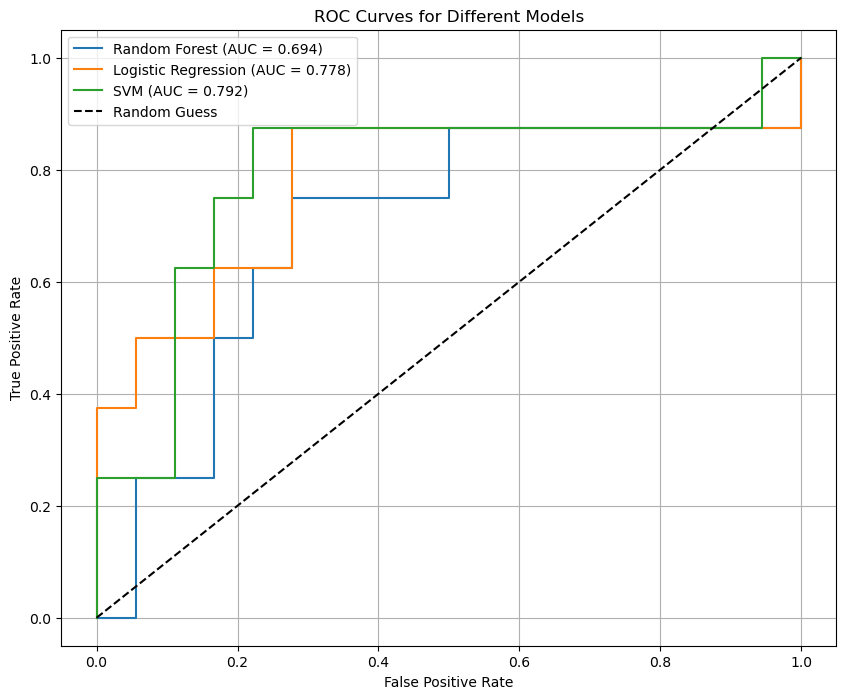

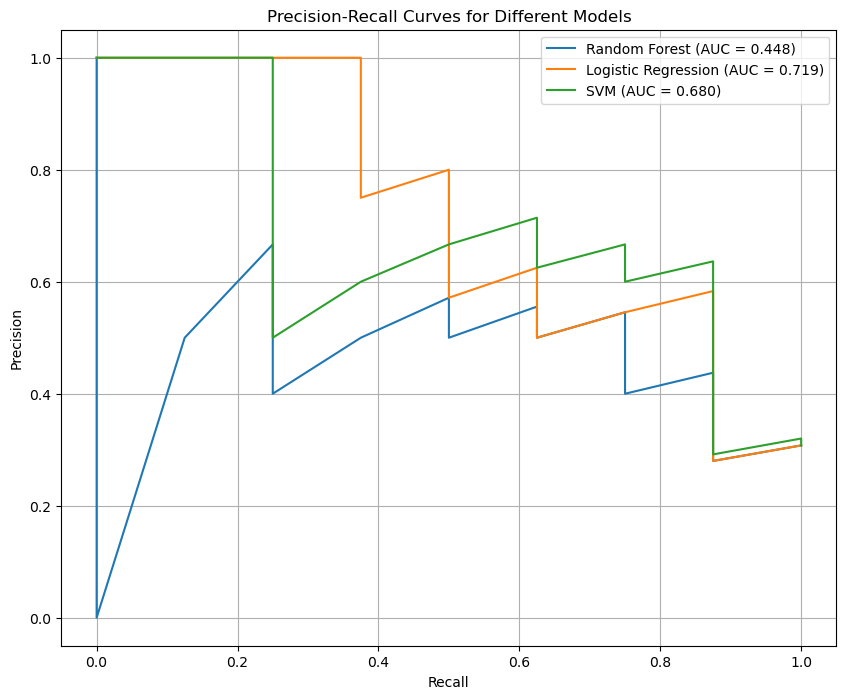

In [306]:
high_mut_metadata = metadata[metadata.index.isin(high_mut.patient_id)]
high_mut_patients = set(high_mut_metadata.index)
high_mutation_matrix = pd.crosstab(
    index=high_mut['patient_id'],
    columns=high_mut['Hugo_Symbol'],
    values=1, 
    aggfunc='count'
)
high_mutation_matrix = high_mutation_matrix.fillna(0)
high_mutation_matrix = high_mutation_matrix[high_mutation_matrix.index.isin(high_mut_patients)]
high_exp_matrix = expression[expression.index.isin(high_mut_patients)]

high_metadata = high_mut_metadata.dropna(subset=['OS', 'OS.time'])
high_metadata['y'] = high_metadata['OS']

common_patients = high_metadata.index.intersection(high_mutation_matrix.index).intersection(high_exp_matrix.index)
X_mut = high_mutation_matrix.loc[common_patients]
X_exp = high_exp_matrix.loc[common_patients]
X_clinical = high_metadata.loc[common_patients, ['age_at_initial_pathologic_diagnosis', 'gender', 'race', 
                                                 'ajcc_pathologic_tumor_stage', 'histological_type', 
                                                 'histological_grade', 'tumor_status']]
y = high_metadata.loc[common_patients, 'y']

# Step 3: Feature Selection
# 3.1: Mutation Features - Filter genes with low mutation frequency (< 5%)
mutation_freq = X_mut.mean()
selected_mut_genes = mutation_freq[mutation_freq >= 0.05].index
X_mut_selected = X_mut[selected_mut_genes]

# 3.2: Gene Expression Features - Standardize and filter low-variance genes
scaler = StandardScaler()
X_exp_scaled = pd.DataFrame(scaler.fit_transform(X_exp), index=X_exp.index, columns=X_exp.columns)
exp_variance = X_exp_scaled.var()
selected_exp_genes = exp_variance[exp_variance > 0.01].index  # Keep genes with variance > 0.01
X_exp_selected = X_exp_scaled[selected_exp_genes]

# 3.3: Clinical Features - Encode categorical variables
# Define which columns are categorical
categorical_cols = ['gender', 'race', 'ajcc_pathologic_tumor_stage', 'histological_type', 'histological_grade', 'tumor_status']
numerical_cols = ['age_at_initial_pathologic_diagnosis']

# Use ColumnTransformer to encode categorical variables
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_cols),
        ('num', 'passthrough', numerical_cols)
    ])

X_clinical_encoded = pd.DataFrame(
    preprocessor.fit_transform(X_clinical),
    index=X_clinical.index,
    columns=(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols).tolist() + numerical_cols)
)

# 3.4: Univariate Feature Selection for Mutation and Expression Features
# For binary features (mutation), use chi-squared test
mut_p_values = {}
for col in X_mut_selected.columns:
    contingency_table = pd.crosstab(X_mut_selected[col], y)
    chi2, p, _, _ = chi2_contingency(contingency_table)
    mut_p_values[col] = p

# t-test
exp_p_values = {}
for col in X_exp_selected.columns:
    group0 = X_exp_selected[col][y == 0]
    group1 = X_exp_selected[col][y == 1]
    t_stat, p = ttest_ind(group0, group1, nan_policy='omit')
    exp_p_values[col] = p

# Select features
selected_mut_features = [col for col, p in mut_p_values.items() if p < 0.1]
selected_exp_features = [col for col, p in exp_p_values.items() if p < 0.1]
X_mut_final = X_mut_selected[selected_mut_features]
X_exp_final = X_exp_selected[selected_exp_features]

X_exp_final = X_exp_final.loc[~X_exp_final.index.duplicated(keep='first')]
X = X_mut_final.join(X_exp_final).join(X_clinical_encoded)
print(X.shape)

X = X.dropna()
print(X.shape)

y = y[y.index.isin(X.index)]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

# Sanitize feature names to remove problematic characters (e.g., [], <)
X_train.columns = [col.replace('[', '').replace(']', '').replace('<', '') for col in X_train.columns]
X_test.columns = [col.replace('[', '').replace(']', '').replace('<', '') for col in X_test.columns]

# Step 5: Train Multiple Models with Cross-Validation
models = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=3000),
    'SVM': SVC(probability=True, random_state=42),
}

# Hyperparameter grids for tuning
param_grids = {
    'Random Forest': {
        'n_estimators': [100, 150, 200, 250, 300],
        'max_depth': [3, 5, 7, 10, 15, 20, None],
        'min_samples_split': [2, 3, 4, 5]
    },
    'Logistic Regression': {
        'C': [0.1, 0.5, 1, 1.5, 2, 4, 5, 8, 10],
        'solver': ['lbfgs', 'liblinear', 'newton-cg', 'sag']
    },
    'SVM': {
        'C': [0.1, 0.5, 1, 1.5, 2, 4, 5, 8, 10],
        'kernel': ['rbf', 'linear']
    },
}

# Dictionary to store the best models and their performance
best_models = {}
metrics = {'Model': [], 'AUC-ROC': [], 'AUC-PR': [], 'Precision': [], 'Recall': [], 'F1': []}
roc_data = {}
pr_data = {}

# Train and evaluate each model
for model_name, model in models.items():
    print(f"\nTraining {model_name}...")
    grid_search = GridSearchCV(model, param_grids[model_name], cv=5, scoring='roc_auc', n_jobs=-1)
    grid_search.fit(X_train, y_train)
    
    # Best model
    best_model = grid_search.best_estimator_
    best_models[model_name] = best_model
    print(f"Best parameters for {model_name}:", grid_search.best_params_)
    
    # Predictions and probabilities
    y_pred = best_model.predict(X_test)
    y_pred_proba = best_model.predict_proba(X_test)[:, 1] if hasattr(best_model, "predict_proba") else best_model.decision_function(X_test)
    
    # Compute metrics
    auc_roc = roc_auc_score(y_test, y_pred_proba)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_data[model_name] = (fpr, tpr, auc_roc)
    
    # Precision-Recall Curve
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_pred_proba)
    auc_pr = auc(recall_vals, precision_vals)
    pr_data[model_name] = (recall_vals, precision_vals, auc_pr)
    
    # Store metrics
    metrics['Model'].append(model_name)
    metrics['AUC-ROC'].append(auc_roc)
    metrics['AUC-PR'].append(auc_pr)
    metrics['Precision'].append(precision)
    metrics['Recall'].append(recall)
    metrics['F1'].append(f1)

# Print metrics in a table
metrics_df = pd.DataFrame(metrics)
print("\nModel Performance Comparison:")
print(metrics_df)

# Step 6: Plot ROC Curves
plt.figure(figsize=(10, 8))
for model_name, (fpr, tpr, auc_roc) in roc_data.items():
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc_roc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Different Models')
plt.legend()
plt.grid()
plt.show()

# Step 7: Plot Precision-Recall Curves
plt.figure(figsize=(10, 8))
for model_name, (recall_vals, precision_vals, auc_pr) in pr_data.items():
    plt.plot(recall_vals, precision_vals, label=f'{model_name} (AUC = {auc_pr:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves for Different Models')
plt.legend()
plt.grid()
plt.show()